## 대형 프로젝트 시작!!

# "가격을 맞혀봐요!" 캡스톤 프로젝트

이번 주 목표 - Amazon 데이터 스크랩을 기반으로 상품 설명에서 가격을 예측하는 모델 만들기

# 진행 순서

1일차: 데이터 수집 및 정제  
2일차: 데이터 전처리  
3일차: 평가, 기준 모델, 전통적 ML  
4일차: 딥러닝과 LLM  
5일차: 프론티어 모델 파인튜닝  

## 1일차: 데이터 수집 및 정제

오늘은 데이터셋을 정리하고 데이터를 큐레이션합니다

데이터셋 위치:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

모든 상품 데이터셋 폴더:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">데이터 수집·정제의 비즈니스 가치</h2>
            <span style="color:#181;">데이터 큐레이션은 데이터 과학자의 화려하지 않은 작업처럼 여겨질 수 있습니다. 하지만 그건 틀린 말입니다!
            진짜 과학이 일어나는 곳이 바로 여기입니다. 데이터와 깊이 씨름하는 것보다 더 흥미로운 일이 있을까요?
            데이터셋에 대한 R&D는 나중에 하는 유행하는 '하이퍼파라미터 최적화'보다
            성능에 더 큰 영향을 미칠 때가 많습니다.
            지금부터 데이터 품질에 진지하게 투자할 시간입니다.</span>
        </td>
    </tr>
</table>

In [1]:
# 임포트

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer.items import Item
from pricer.parser import parse
load_dotenv(override=True)

True

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

In [3]:
# HuggingFace 로그인 - 환경변수 관련 "Note" 메시지가 나와도 무시하세요

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 데이터셋 불러오기

다음 셀에서 HuggingFace로부터 데이터셋을 불러옵니다.

"trust_remote_code is no longer supported"와 같은 오류가 발생하면, 새 셀에서 다음 명령을 실행하세요:  
`!uv add --upgrade datasets==3.6.0`  
그런 다음 커널을 재시작하고 다시 시도하세요.

In [4]:
import datasets
print(datasets.__version__)  # 2.21.0 이 나와야 함

2.21.0


In [5]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", trust_remote_code=True)

In [6]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 94,327


In [7]:
# 특정 데이터 포인트 살펴보기

dataset[6]


{'main_category': 'Appliances',
 'title': 'WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003',
 'average_rating': 4.6,
 'rating_number': 323,
 'features': ['【PARTS NUMBER】The WD12X10327 dishwasher top rack wheels and stud assembly Kit （4 pcs）',
  '【SCOPE OF APPLICATION】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud',
  '【REPLACES PART】1811003, AP4980629, WD12X0330, WD12X0356, WD12X0357, WD12X0383, WD12X0385, WD12X10327, WD12X330, WD12X356, WD12X357, WD12X383, WD12X385',
  '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure',
  '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask

In [8]:

# 가장 비싼 상품은?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"가장 비싼 상품: {max_item['title']} / 가격: ${max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

가장 비싼 상품: TurboChef BULLET Rapid Cook Electric Microwave Convection Oven / 가격: $21,095.62


제가 찾을 수 있는 가장 비싼 제품입니다 - 엄청 저렴한 가격에 팔리고 있네요!!

https://www.amazon.com/TurboChef-Electric-Countertop-Microwave-Convection/dp/B01D05U9NO/

In [9]:
# 가격이 $1~$1000 범위이고 충분한 정보가 있는 항목을 Item 객체로 불러오기

items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"전체 {len(dataset):,}개 데이터 포인트 중 {len(items):,}개 항목 로드 완료")

  0%|          | 0/94327 [00:00<?, ?it/s]

전체 94,327개 데이터 포인트 중 35,307개 항목 로드 완료


In [10]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [11]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

In [12]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

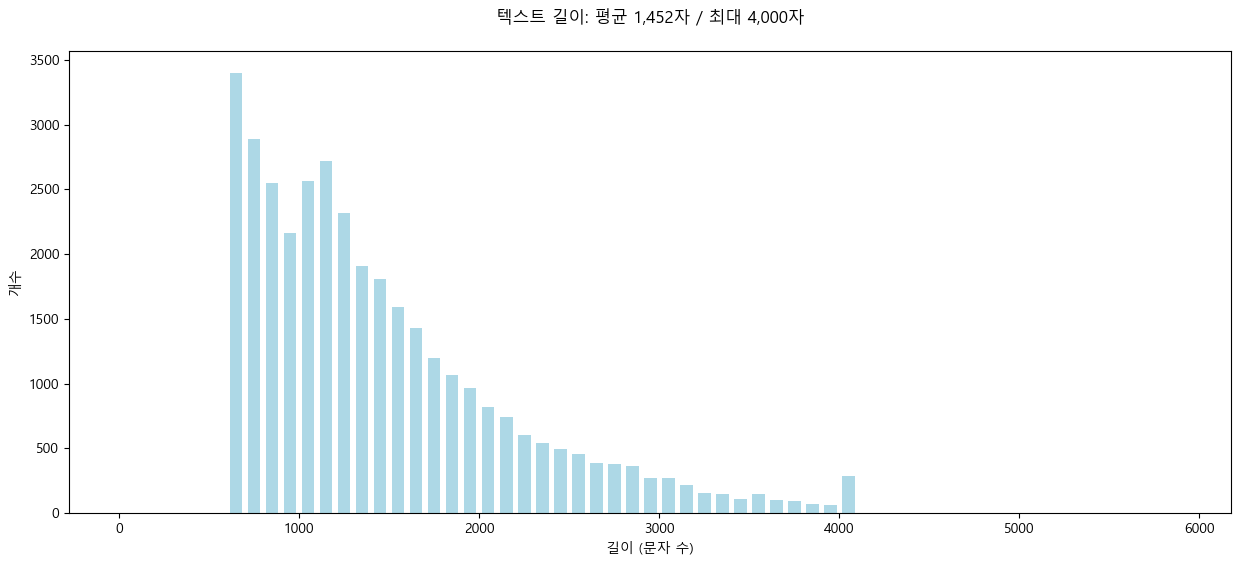

In [13]:
# 텍스트 길이 분포 시각화

plt.figure(figsize=(15, 6))
plt.title(f"텍스트 길이: 평균 {sum(lengths)/len(lengths):,.0f}자 / 최대 {max(lengths):,}자\n")
plt.xlabel('길이 (문자 수)')
plt.ylabel('개수')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [14]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)


Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig

Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.


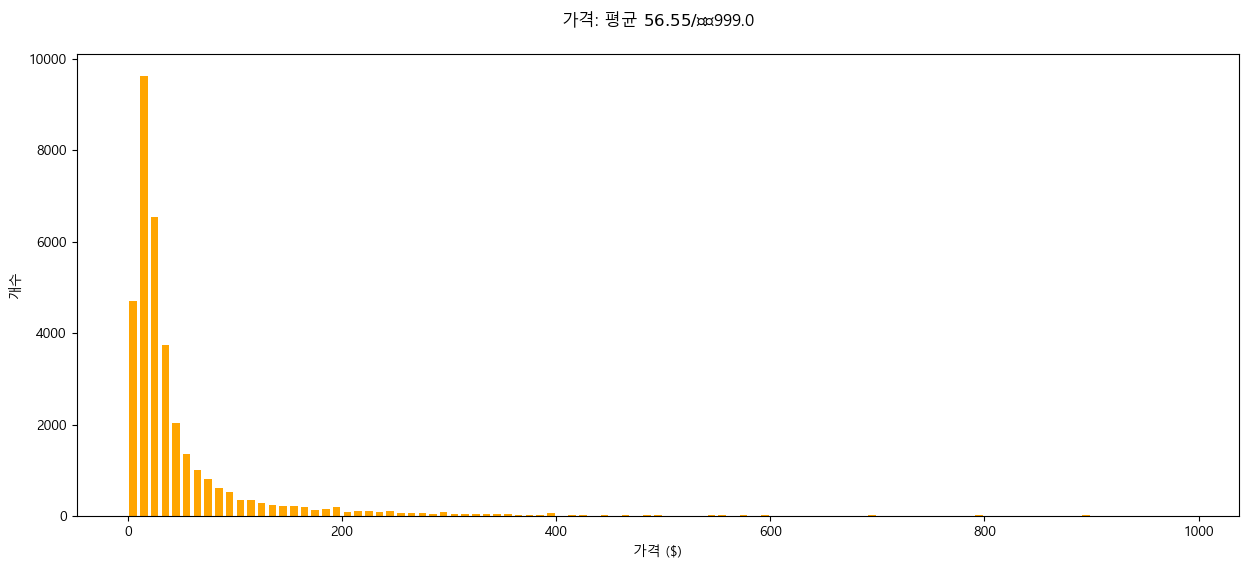

In [15]:
# 가격 분포 시각화
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 ${sum(prices)/len(prices):,.2f} / 최대 ${max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [16]:
print(items[3].full)

MLGB Stainless Steel Brushed Pattern Dishwasher Magnet Cover Panel Decal Home Appliance Art, Stainless Steel Fridge Door Cover Decals Magnetic, Black, Mobile Magnetic 23" x 26"
['Stainless Steel Brushed Pattern Magnetic Dishwasher Panel Covers allow you to easily transform your kitchen as the seasons change. You can instantly get rid of outdated and/or mismatched appliances, will give your kitchen a refreshing look.', ':', 'Vinyl + rubber magnet', 'Occasion:', 'Magnet Dishwasher Cover Decor dishwasher covers and any metal device surface with magnetism.', '【Kitchen Dishwasher Covers SIZE】S - 23 W x 17 H inches; 58.5 W x 43 H cm;L - 23 W x 26 H inches; 58.5 W x 66 H cm;', 'Attention:', 'Just ensure that your dishwasher is magnetic before ordering the dishwasher cover magnet', 'Due to the inconsistent calibration of the monitor, the colors on the computer monitor may be slightly different.', 'Quality service:', 'If you have any questions or questions, please feel free to contact us and we

In [17]:
from pricer.loaders import ItemLoader
loader = ItemLoader("Appliances")
items = loader.load()


Loading dataset Appliances
  진행 중: 10/95 청크 완료 (4,518개 항목)
  진행 중: 20/95 청크 완료 (8,839개 항목)
  진행 중: 30/95 청크 완료 (12,952개 항목)
  진행 중: 40/95 청크 완료 (16,923개 항목)
  진행 중: 50/95 청크 완료 (20,775개 항목)
  진행 중: 60/95 청크 완료 (24,521개 항목)
  진행 중: 70/95 청크 완료 (28,029개 항목)
  진행 중: 80/95 청크 완료 (31,463개 항목)
  진행 중: 90/95 청크 완료 (34,234개 항목)
  진행 중: 95/95 청크 완료 (35,307개 항목)
Completed Appliances with 35,307 datapoints in 0.5 mins


In [18]:
dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [19]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Automotive
  진행 중: 10/2004 청크 완료 (5,982개 항목)
  진행 중: 20/2004 청크 완료 (11,989개 항목)
  진행 중: 30/2004 청크 완료 (17,957개 항목)
  진행 중: 40/2004 청크 완료 (23,815개 항목)
  진행 중: 50/2004 청크 완료 (29,805개 항목)
  진행 중: 60/2004 청크 완료 (35,738개 항목)
  진행 중: 70/2004 청크 완료 (41,712개 항목)
  진행 중: 80/2004 청크 완료 (47,657개 항목)
  진행 중: 90/2004 청크 완료 (53,535개 항목)
  진행 중: 100/2004 청크 완료 (59,360개 항목)
  진행 중: 110/2004 청크 완료 (65,204개 항목)
  진행 중: 120/2004 청크 완료 (71,102개 항목)
  진행 중: 130/2004 청크 완료 (77,000개 항목)
  진행 중: 140/2004 청크 완료 (82,786개 항목)
  진행 중: 150/2004 청크 완료 (88,560개 항목)
  진행 중: 160/2004 청크 완료 (94,349개 항목)
  진행 중: 170/2004 청크 완료 (100,178개 항목)
  진행 중: 180/2004 청크 완료 (105,977개 항목)
  진행 중: 190/2004 청크 완료 (111,681개 항목)
  진행 중: 200/2004 청크 완료 (117,546개 항목)
  진행 중: 210/2004 청크 완료 (123,288개 항목)
  진행 중: 220/2004 청크 완료 (129,080개 항목)
  진행 중: 230/2004 청크 완료 (134,931개 항목)
  진행 중: 240/2004 청크 완료 (140,645개 항목)
  진행 중: 250/2004 청크 완료 (146,357개 항목)
  진행 중: 260/2004 청크 완료 (152,046개 항목)
  진행 중: 270/2004 청크 완료 (157,797개 항목)


Generating full split:   0%|          | 0/890874 [00:00<?, ? examples/s]

  진행 중: 10/891 청크 완료 (4,989개 항목)
  진행 중: 20/891 청크 완료 (9,926개 항목)
  진행 중: 30/891 청크 완료 (14,781개 항목)
  진행 중: 40/891 청크 완료 (19,634개 항목)
  진행 중: 50/891 청크 완료 (24,438개 항목)
  진행 중: 60/891 청크 완료 (29,173개 항목)
  진행 중: 70/891 청크 완료 (33,880개 항목)
  진행 중: 80/891 청크 완료 (38,558개 항목)
  진행 중: 90/891 청크 완료 (43,210개 항목)
  진행 중: 100/891 청크 완료 (47,879개 항목)
  진행 중: 110/891 청크 완료 (52,536개 항목)
  진행 중: 120/891 청크 완료 (57,140개 항목)
  진행 중: 130/891 청크 완료 (61,794개 항목)
  진행 중: 140/891 청크 완료 (66,414개 항목)
  진행 중: 150/891 청크 완료 (70,903개 항목)
  진행 중: 160/891 청크 완료 (75,470개 항목)
  진행 중: 170/891 청크 완료 (79,968개 항목)
  진행 중: 180/891 청크 완료 (84,512개 항목)
  진행 중: 190/891 청크 완료 (89,090개 항목)
  진행 중: 200/891 청크 완료 (93,582개 항목)
  진행 중: 210/891 청크 완료 (98,017개 항목)
  진행 중: 220/891 청크 완료 (102,401개 항목)
  진행 중: 230/891 청크 완료 (106,739개 항목)
  진행 중: 240/891 청크 완료 (110,986개 항목)
  진행 중: 250/891 청크 완료 (115,307개 항목)
  진행 중: 260/891 청크 완료 (119,568개 항목)
  진행 중: 270/891 청크 완료 (123,785개 항목)
  진행 중: 280/891 청크 완료 (128,003개 항목)
  진행 중: 290/891 청크 완료 (1

Generating full split:   0%|          | 0/213593 [00:00<?, ? examples/s]

  진행 중: 10/214 청크 완료 (4,378개 항목)
  진행 중: 20/214 청크 완료 (8,571개 항목)
  진행 중: 30/214 청크 완료 (12,522개 항목)
  진행 중: 40/214 청크 완료 (16,501개 항목)
  진행 중: 50/214 청크 완료 (20,303개 항목)
  진행 중: 60/214 청크 완료 (24,076개 항목)
  진행 중: 70/214 청크 완료 (27,711개 항목)
  진행 중: 80/214 청크 완료 (31,209개 항목)
  진행 중: 90/214 청크 완료 (34,608개 항목)
  진행 중: 100/214 청크 완료 (38,045개 항목)
  진행 중: 110/214 청크 완료 (41,378개 항목)
  진행 중: 120/214 청크 완료 (44,522개 항목)
  진행 중: 130/214 청크 완료 (47,759개 항목)
  진행 중: 140/214 청크 완료 (50,891개 항목)
  진행 중: 150/214 청크 완료 (53,855개 항목)
  진행 중: 160/214 청크 완료 (56,881개 항목)
  진행 중: 170/214 청크 완료 (59,811개 항목)
  진행 중: 180/214 청크 완료 (62,575개 항목)
  진행 중: 190/214 청크 완료 (64,824개 항목)
  진행 중: 200/214 청크 완료 (66,527개 항목)
  진행 중: 210/214 청크 완료 (68,266개 항목)
  진행 중: 214/214 청크 완료 (68,855개 항목)
Completed Musical_Instruments with 68,855 datapoints in 2.6 mins


In [20]:
print(f"A grand total of {len(items):,} items")

A grand total of 2,933,577 items


In [21]:
items[1000]

<Coolant Temperature Sensor Compatible with Volvo V70 850 S70 960 C70 S90 V90 1997-1998 = $26.7>

In [22]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"중복 제거 후 남은 항목 수: {len(items):,}개")

  0%|          | 0/2933577 [00:00<?, ?it/s]

  0%|          | 0/2889429 [00:00<?, ?it/s]

중복 제거 후 남은 항목 수: 2,887,890개


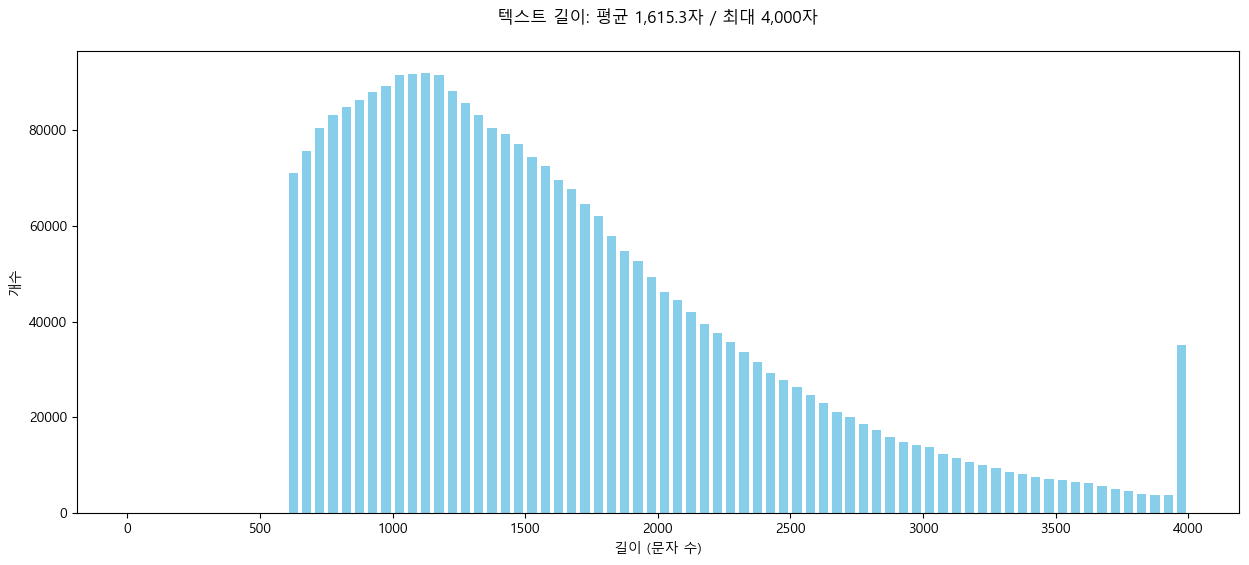

In [23]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"텍스트 길이: 평균 {sum(lengths)/len(lengths):,.1f}자 / 최대 {max(lengths):,}자\n")
plt.xlabel('길이 (문자 수)')
plt.ylabel('개수')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ucd5c' [U+cd5c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.


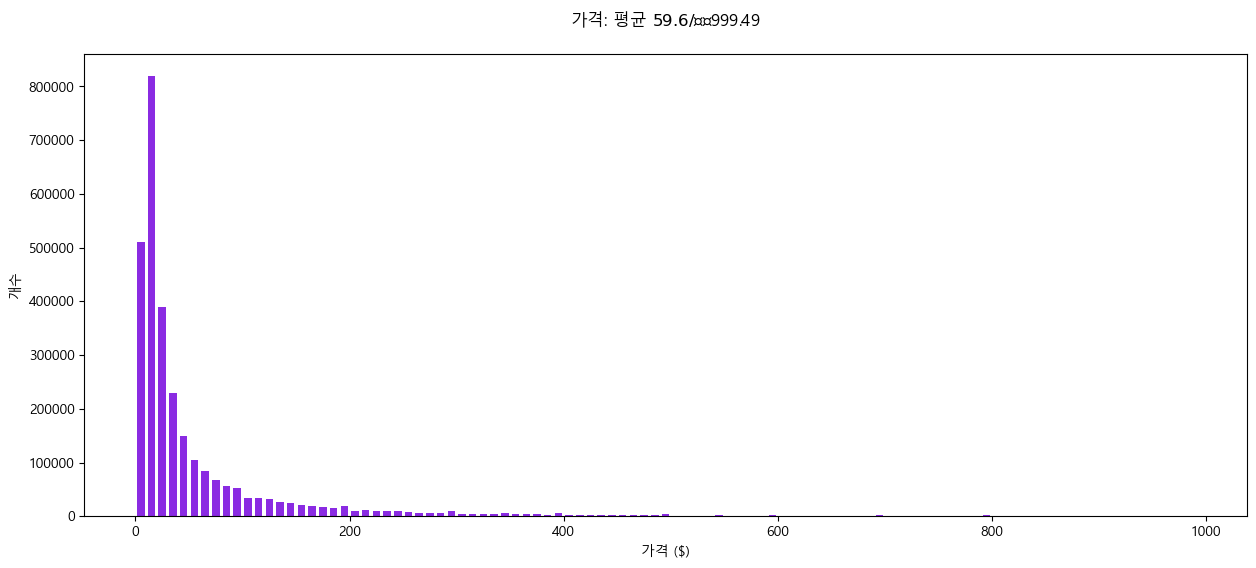

In [24]:
# 가격 분포 시각화

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 ${sum(prices)/len(prices):,.1f} / 최대 ${max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

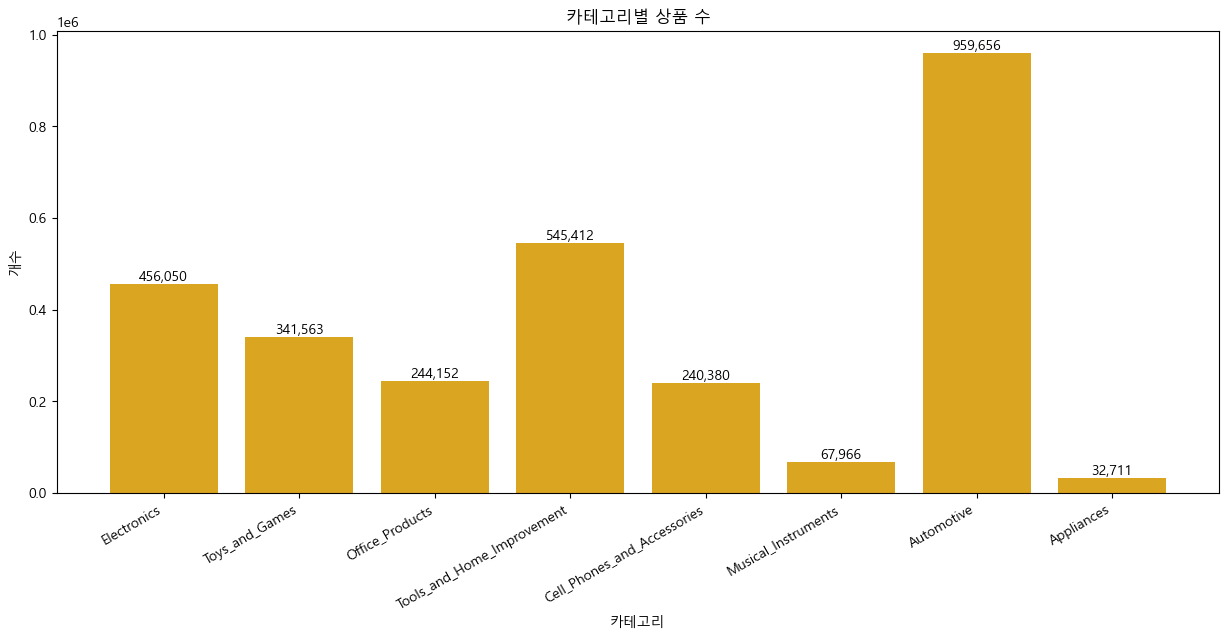

In [25]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('카테고리별 상품 수')
plt.xlabel('카테고리')
plt.ylabel('개수')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [26]:
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]


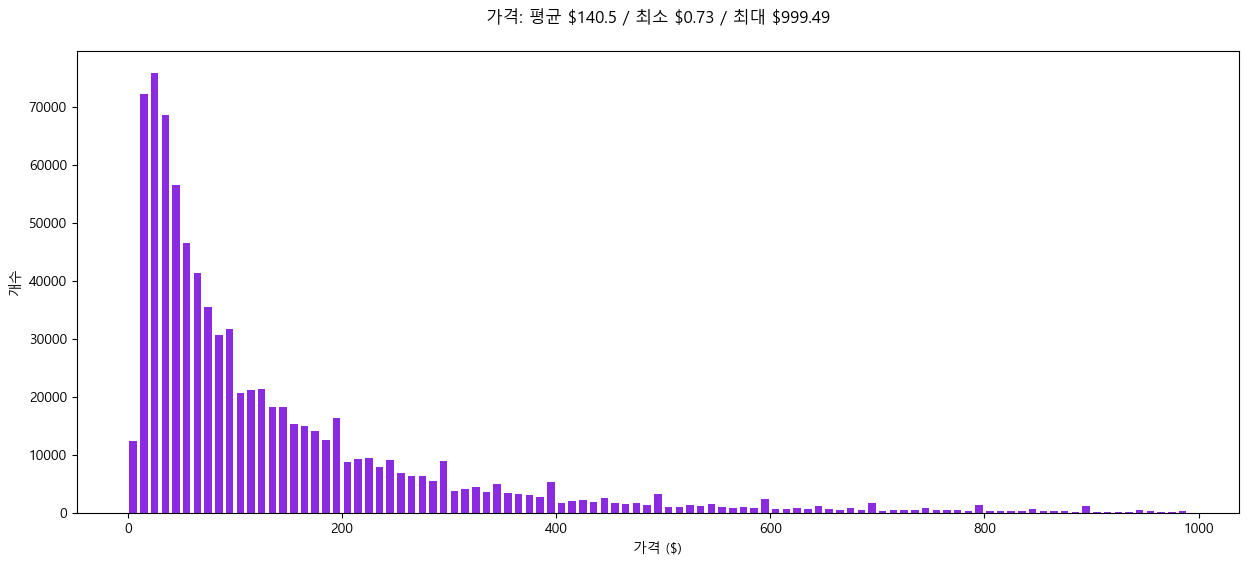

In [27]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 ${sum(prices)/len(prices):,.1f} / 최소 ${min(prices):,} / 최대 ${max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [28]:
# 최종 데이터셋을 위해 샘플을 한 번 더 셔플

random.seed(42)
random.shuffle(sample)


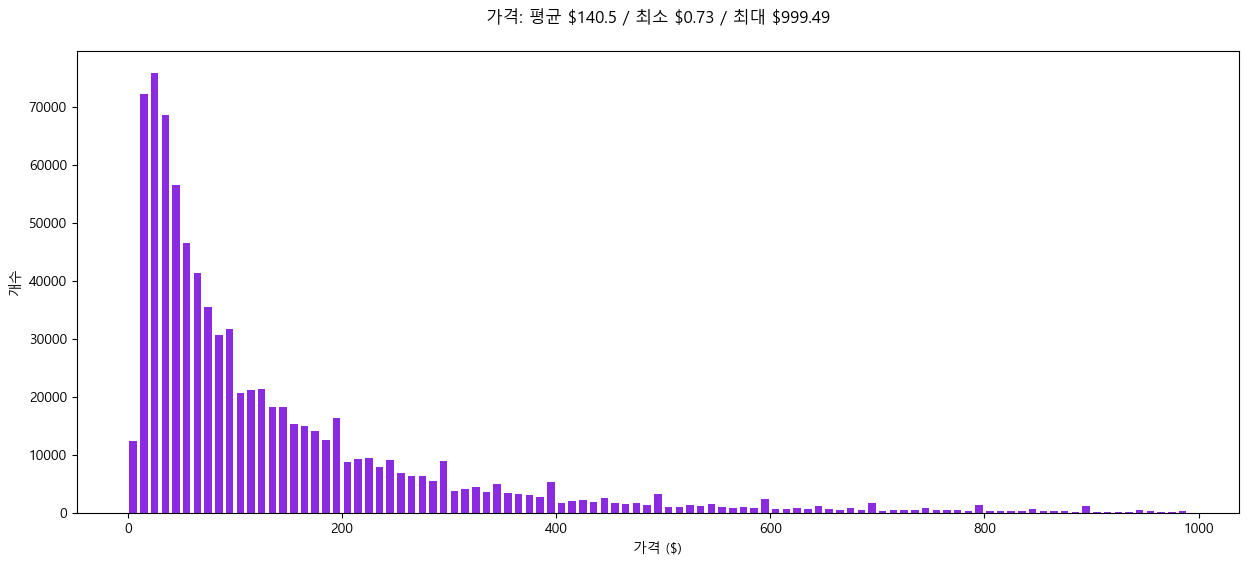

In [29]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"가격: 평균 ${sum(prices)/len(prices):,.1f} / 최소 ${min(prices):,} / 최대 ${max(prices):,}\n")
plt.xlabel('가격 ($)')
plt.ylabel('개수')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

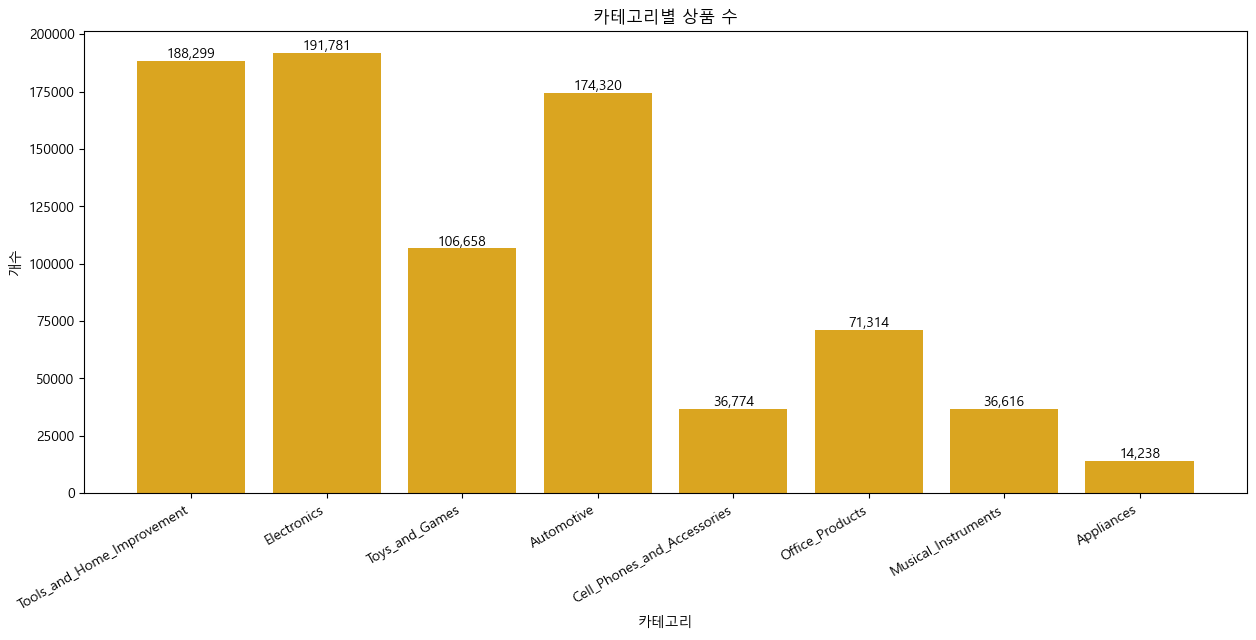

In [30]:
from collections import Counter
category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# 카테고리별 막대 그래프
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('카테고리별 상품 수')
plt.xlabel('카테고리')
plt.ylabel('개수')

plt.xticks(rotation=30, ha='right')

# 막대 위에 값 표시
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# 차트 출력
plt.show()

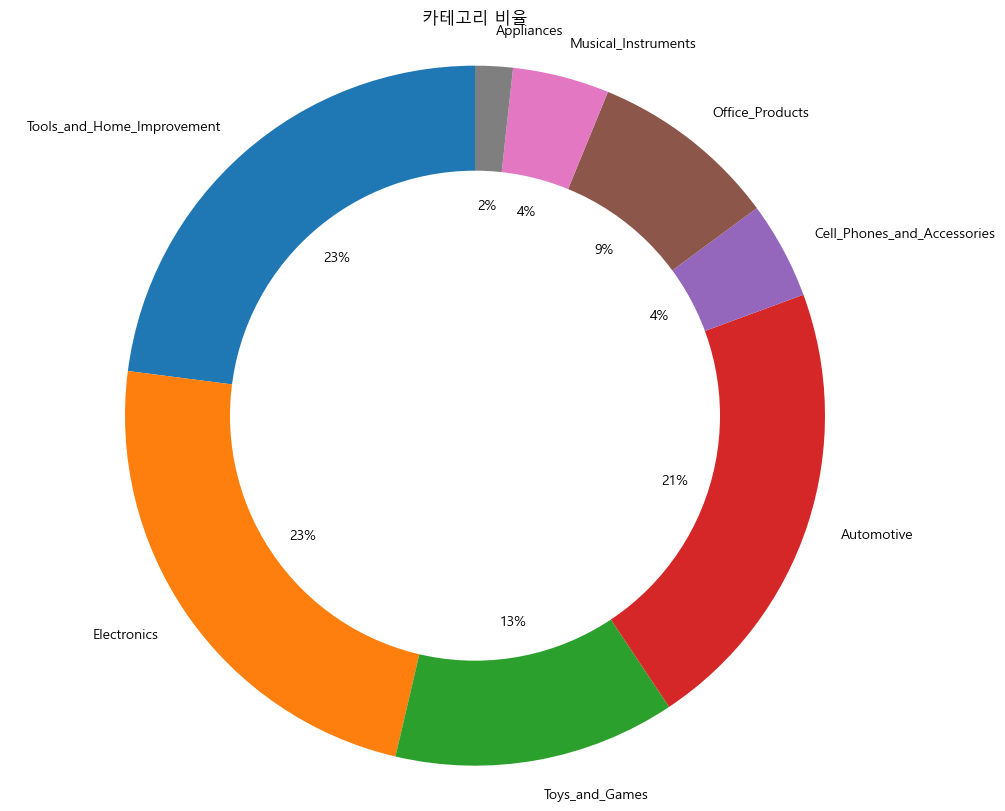

In [31]:
# Automotive가 여전히 1위이지만 어느 정도 개선되었습니다
# 다른 관점에서 파이 차트로 살펴보겠습니다

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# 도넛 차트 만들기 (선택 사항)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('카테고리 비율')

# 원형 비율 유지
plt.axis('equal')  

plt.show()

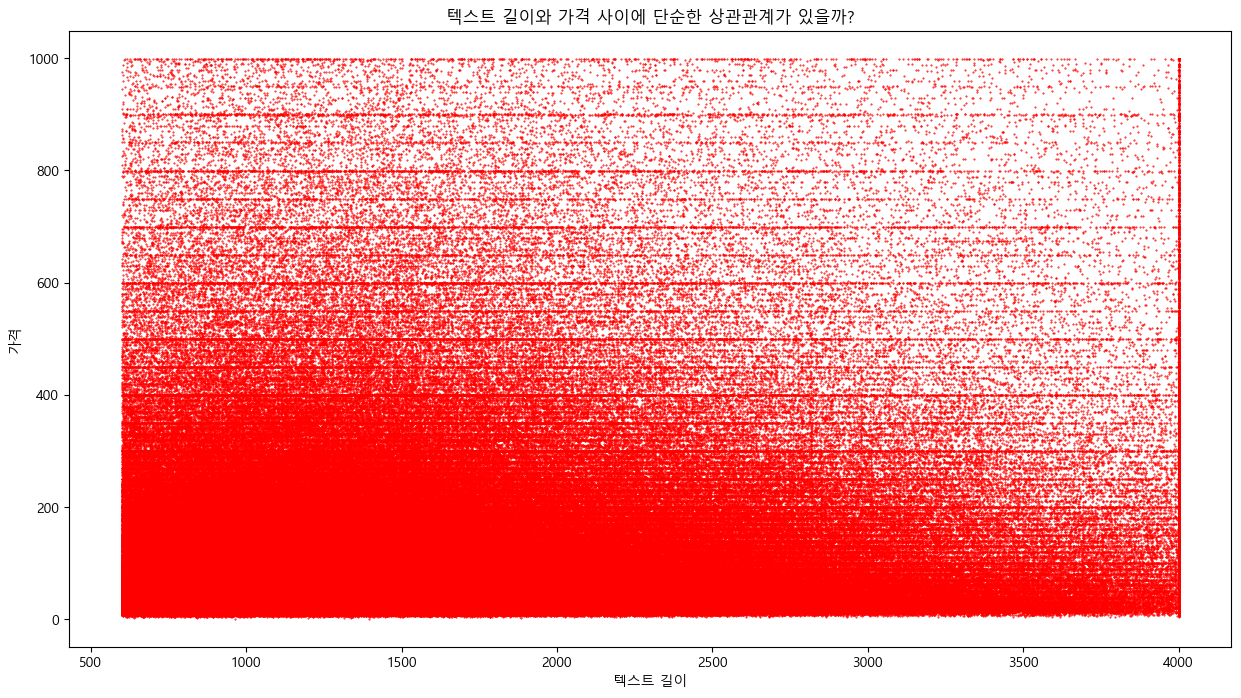

In [32]:
# 텍스트 길이와 가격의 상관관계가 있을까?

sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# 산점도 생성
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# 레이블 및 제목 추가
plt.xlabel('텍스트 길이')
plt.ylabel('가격')
plt.title('텍스트 길이와 가격 사이에 단순한 상관관계가 있을까?')

# 그래프 출력
plt.show()

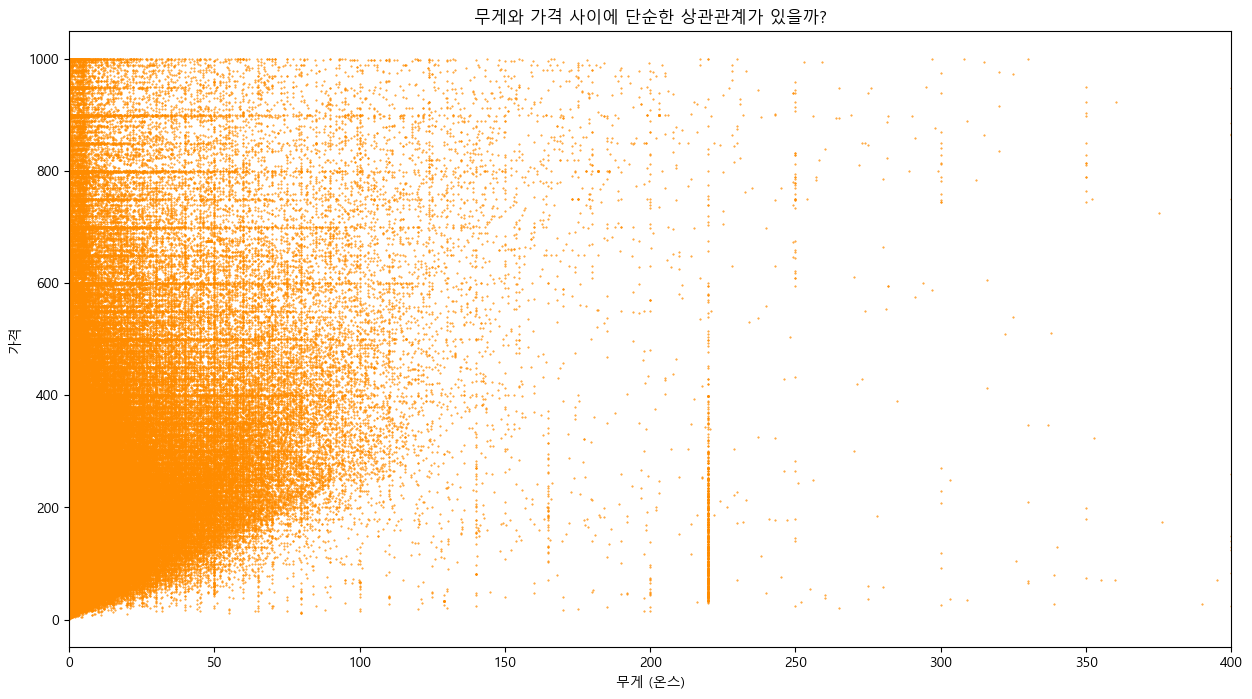

In [33]:
# 무게와 가격의 상관관계가 있을까?

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

# 산점도 생성
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# 레이블 및 제목 추가
plt.xlabel('무게 (온스)')
plt.ylabel('가격')
plt.xlim(0, 400)
plt.title('무게와 가격 사이에 단순한 상관관계가 있을까?')

# 그래프 출력
plt.show()

## 이제 이 데이터셋을 HuggingFace Hub에 업로드합니다

직접 데이터셋을 만들었다면 username을 본인의 HF 사용자명으로 변경하세요

또는 이 셀을 건너뛰고 내일 제가 만든 데이터셋을 불러올 수 있습니다!

In [35]:
username = "oing98"
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_000:810_000]
test = sample[810_000:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Uploading the dataset shards:   0%|          | 0/3 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/267 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Creating parquet from Arrow format:   0%|          | 0/267 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


## 참고

matplotlib에서 사용할 수 있는 다양한 색상이 궁금하다면, 이 링크를 북마크해두세요:

https://matplotlib.org/stable/gallery/color/named_colors.html
